In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'darkgrid')

# Scatterplot

Relating variables with scatter plots

In [13]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


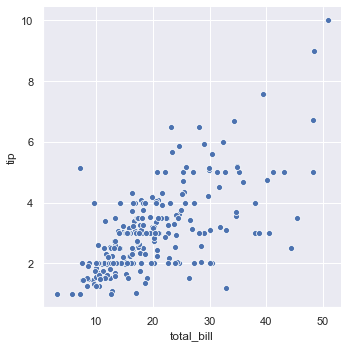

In [9]:

sns.relplot(x = 'total_bill', y = 'tip', data = tips, kind = 'scatter')

While the points are plotted in two dimensions, another dimension can be added to the plot by coloring the points according to a third variable. In seaborn, this is referred to as using a “hue semantic”, because the color of the point gains meaning

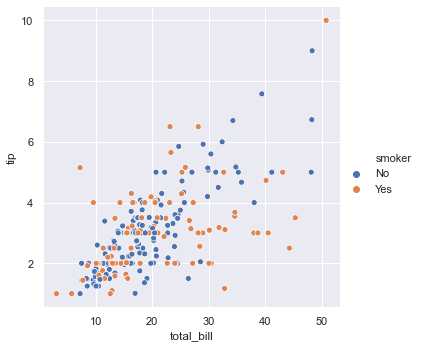

In [10]:
sns.relplot(x = 'total_bill', y = 'tip', data = tips, hue = 'smoker', kind = 'scatter')

To emphasize the difference between the classes, and to improve accessibility, you can use a different marker style for each class

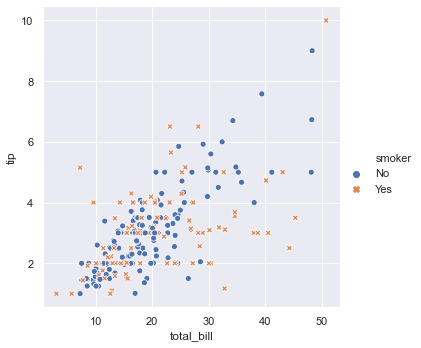

In [11]:
sns.relplot(x = 'total_bill', y = 'tip', kind = 'scatter', hue = 'smoker', style = 'smoker', data = tips)

It’s also possible to represent four variables by changing the hue and style of each point independently. But this should be done carefully, because the eye is much less sensitive to shape than to color:

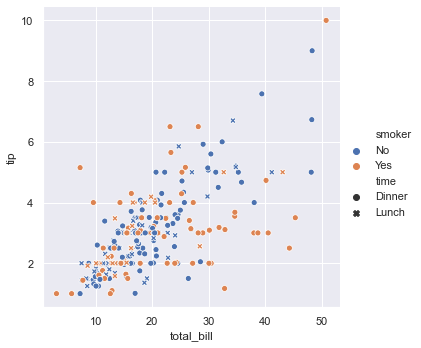

In [15]:
sns.relplot(x = 'total_bill', y = 'tip', kind = 'scatter', hue = 'smoker', style = 'time', data = tips)

In the examples above, the hue semantic was categorical, so the default qualitative palette was applied. If the hue semantic is numeric (specifically, if it can be cast to float), the default coloring switches to a sequential palette

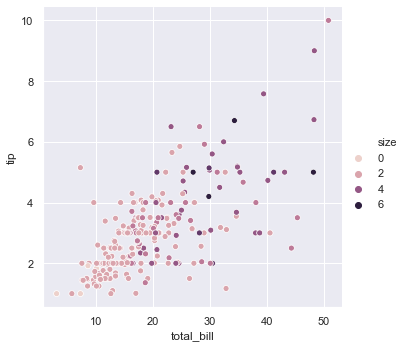

In [16]:
sns.relplot(x = 'total_bill', y = 'tip', hue = 'size', data = tips)

In both cases, you can customize the color palette. There are many options for doing so. Here, we customize a sequential palette using the string interface to cubehelix_palette()

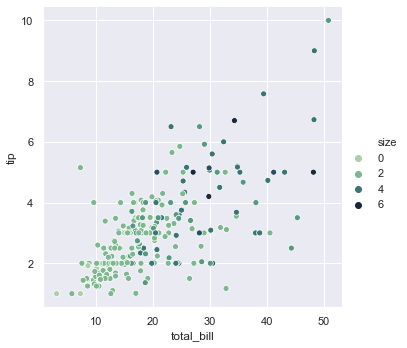

In [38]:
sns.relplot(x = 'total_bill', y = 'tip', hue = 'size', palette = 'ch:r=-.5, l = .75', data = tips)

The third kind of semantic variable changes the size of each point

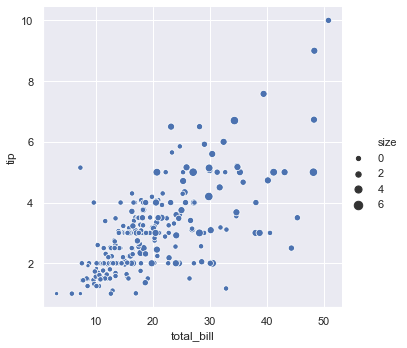

In [40]:
sns.relplot(x = 'total_bill', y = 'tip', size = 'size', data = tips, kind = 'scatter')

Unlike with matplotlib.pyplot.scatter(), the literal value of the variable is not used to pick the area of the point. Instead, the range of values in data units is normalized into a range in area units. This range can be customized

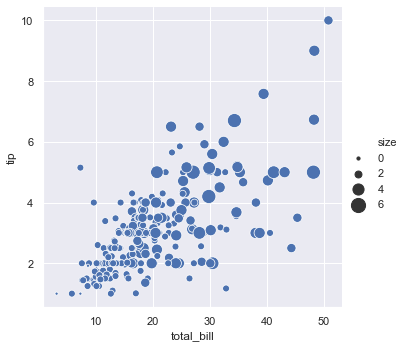

In [45]:
sns.relplot(x = 'total_bill', y = 'tip', size = 'size', sizes = (10,200), data = tips, kind = 'scatter')



# Line plot

Emphasizing continuity with line plots

Scatter plots are highly effective, but there is no universally optimal type of visualisation. Instead, the visual representation should be adapted for the specifics of the dataset and to the question you are trying to answer with the plot.

With some datasets, you may want to understand changes in one variable as a function of time, or a similarly continuous variable. In this situation, a good choice is to draw a line plot. In seaborn, this can be accomplished by the lineplot() function, either directly or with relplot() by setting kind="line"

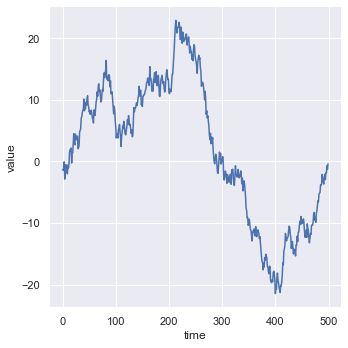

In [53]:
df = pd.DataFrame({'time': np.arange(500),
                   'value': np.random.randn(500).cumsum()})
g = sns.relplot(x = 'time', y = 'value', kind = 'line', data = df)
#g.fig.autofmt_xdate()



Because lineplot() assumes that you are most often trying to draw y as a function of x, the default behavior is to sort the data by the x values before plotting. However, this can be disabled

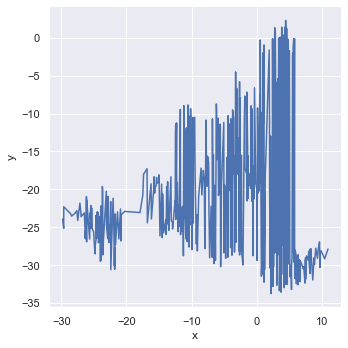

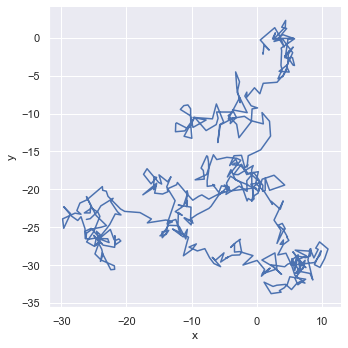

In [56]:
df = pd.DataFrame(np.random.randn(500,2).cumsum(axis=0), columns = ['x', 'y'])
sns.relplot(x = 'x', y = 'y', sort = True, kind = 'line', data = df)
sns.relplot(x = 'x', y = 'y', sort = False, kind = 'line', data = df)

### Aggregation and representing uncertainty

# Color palette with cubehelix_palette()

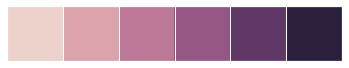

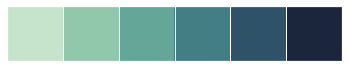

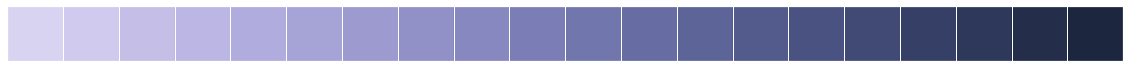

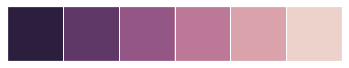

In [29]:
# https://seaborn.pydata.org/generated/seaborn.cubehelix_palette.html#seaborn.cubehelix_palette
sns.palplot(sns.cubehelix_palette())
sns.palplot(sns.cubehelix_palette(rot = -.4))
sns.palplot(sns.cubehelix_palette(n_colors = 20, start = 2.8, rot = .1))
sns.palplot(sns.cubehelix_palette(reverse = True))

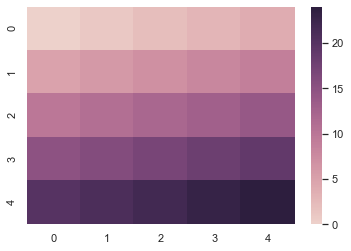

In [34]:
# Generate a colormap object
x = np.arange(25).reshape(5,5)
cmap = sns.cubehelix_palette(as_cmap = True)
ax = sns.heatmap(x, cmap = cmap)

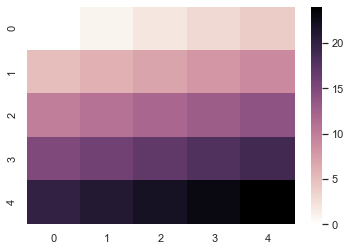

In [35]:
cmap = sns.cubehelix_palette(dark = 0, light = 1, as_cmap = True)
ax = sns.heatmap(x, cmap = cmap)